In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 

import torch 
import torch.nn as nn 
import torch.optim as optim 
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets,transforms 

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#model = model.to(device)

device

device(type='cpu')

In [ ]:
#Preprocessing to images data 

train_transform = transforms.Compose([ 
    transforms.Resize((128,128)), 
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(10), 
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]) 
                                      ])

test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
                         ])

val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
]) 

In [ ]:
#Dataset Path

#
#data_root = "D:/DEEP LEARNING/Pneumonia Xchest Detection/chest_xray"

In [ ]:
# Data Loading from Google Drive 

from google.colab import drive 

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir() 

['.config', 'drive', 'sample_data']

In [ ]:
import torch

# Try TPU detection
try:
    import torch_xla.core.xla_model as xm
    device = xm.xla_device() 
    print("tpu")
except ImportError:
    # Fallback to GPU or CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("cuda" if torch.cuda.is_available() else "cpu")


cpu


In [ ]:
data_root = "/content/drive/MyDrive/chest_xray"

In [ ]:
#Data Loading

train_data = datasets.ImageFolder(root = data_root+"/train",transform=train_transform)

test_data = datasets.ImageFolder(root = data_root+"/test",transform=test_transform)

val_data = datasets.ImageFolder(root = data_root+"/val",transform=val_transform)

In [ ]:
print(train_data) 
print(test_data) 

Dataset ImageFolder
    Number of datapoints: 5208
    Root location: /content/drive/MyDrive/chest_xray/train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )
Dataset ImageFolder
    Number of datapoints: 624
    Root location: /content/drive/MyDrive/chest_xray/test
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )


In [ ]:
#Create Loaders 

train_loader = DataLoader(train_data,batch_size=32,
                          shuffle=True,num_workers=2,pin_memory=True) 

test_loader = DataLoader(test_data,batch_size =32,
                         shuffle=True,num_workers=2,pin_memory=True)

val_loader = DataLoader(val_data, batch_size=32,
                        shuffle=True,num_workers=2,pin_memory=True) 


In [ ]:
#To set up classes 

class_names = train_data.classes
NUM_CLASSES = len(class_names) 
print(NUM_CLASSES)
class_names

2


['NORMAL', 'PNEUMONIA']

In [ ]:
#In Case of Custom Dataset making

class MyDataset(Dataset):
    
    #Load metadata(paths,labels)
    def __init__(self,data,labels):
        self.data = data
        self.labels = labels
        
    #return number of samples         
    def __len__(self):
        return len(self.data)
    
    #Load one sample(image+label)
    def __getitem__(self,idx):
        image = self.data[idx] #Get data at this index 
        label = torch.tensor(self.labels[idx],dtype=torch.long) #Will convert label get at index into a pytorch tensor 
        
        return image,label
        

In [ ]:
#Model Defining


class CNN(nn.Module): #Inherit from Module
    
    def __init__(self,num_classes): 
        super(CNN,self).__init__() #Call nn.Module function to apply,...runs Pytorch own's setup
        

        #Convolutional Layers 
        #These layers detect patterns(edges,textures,lung anomalies),extract features on the images 
        self.conv = nn.Sequential(  
            nn.Conv2d(3,32,3,padding="same"), 
            nn.BatchNorm2d(32), 
            nn.ReLU(),  
            nn.MaxPool2d(2), 
            #nn.Dropout2d(0.1),
           
            nn.Conv2d(32,64,3,padding="same"),
            nn.BatchNorm2d(64),   
            nn.ReLU(),   
            nn.MaxPool2d(2), 
            
            nn.Conv2d(64,128,3,padding = "same"),
            nn.BatchNorm2d(128),   
            nn.ReLU(), 
            nn.MaxPool2d(2) ,  #32x32 → 16x16 (image size)
            
            nn.Conv2d(128,256,3,padding="same"),
            nn.BatchNorm2d(256),
            nn.ReLU(),  
            nn.MaxPool2d(2) #16x16 -> 8x8 
        ) 
        
         
        #Sequential Layers (The classifier, decide class) 
        self.fc = nn.Sequential(   
            nn.Linear(256*8*8,256),  
            nn.BatchNorm1d(256), 
            nn.ReLU(), 
            nn.Linear(256,128),  
            nn.BatchNorm1d(128),  
            nn.ReLU(),  
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            #nn.Dropout(0.1), 
            nn.Linear(64,num_classes)#This last layer has 2 classes(number of classes we have),128  #Last layer, no activatiuon here because of CrossEntropyLoss will apply softmax
        )  
        
        
    def forward(self,x):
        
        x = self.conv(x) #Apply convolution 
        x = torch.flatten(x,1) #Flatten conv layers output (3D blob → 1D vector)
        x = self.fc(x) #Fully connected classifier 
        
        return x

num_classes = len(train_data.classes) 

model = CNN(num_classes).to(device)


In [ ]:
model

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()


In [ ]:
#Defining loss and optimizer 

from tqdm import tqdm 
import time 


criterion = nn.CrossEntropyLoss() #Loss function 

optimizer = optim.Adam(model.parameters(),lr=0.001)#Adam optimizer, will optimize model's weights 
        
scheduler = optim.lr_scheduler.ReduceLROnPlateau( #Learning rate scheduler, will reduce learning rate when no improving till 2 epochs 
    optimizer, factor = 0.5, patience = 2) 


#TRAINING LOOP

#List to store losses and accuracy 
train_losses = []
val_losses = []
train_accs = []
val_accs = []

EPOCHS = 10


best_val_loss = float("inf") #To track the best validation loss seen so far. 


for epoch in range(EPOCHS):
     
    model.train()
    
    #Variables to accumulate loss and correct predictions for batches 
    running_loss = 0 #Counts batches loss 
    correct_train = 0 #counts correctly classified images per batch 
    total_train = 0 #Counts total images seen 
    

    #Loop through each batch from the DataLoader
    #Wraps the DataLoader in a progress bar(tqdm). desc sets the label shown on the left. Leave=True keeps the bar visible after the epoch finishes 
    loop = tqdm(train_loader,desc = f"Epoch[{epoch+1}/{EPOCHS}]",leave =True)
    
    
    for images,labels in loop:
        
        images = images.to(device)  
        labels = labels.to(device)
        
        #Clears the gradients from the previous batch.   
        optimizer.zero_grad()

        outputs = model(images) #Forward pass
        
        loss = criterion(outputs,labels) #Compute the losses 

        loss.backward() #backpropagation
        
        optimizer.step() #Update all weights using the gradients 
        
        running_loss += loss.item() #Accumulate each batch loss 

        _,predicted = torch.max(outputs,1)  #This will find the index of the highest score of each image class predicted and that index is the predicted class 
       
        
        total_train += labels.size(0) #Counts Total number of images processed 


        
        #count how many predictions matches real labels 
        correct_train += (predicted == labels).sum().item()
        
        #Update tqdm description
        loop.set_postfix(loss=running_loss/total_train,acc=correct_train/total_train)
        
        
    #Calculate average loss and accuracy for this epoch 
    train_loss = running_loss/len(train_loader)
    train_acc = correct_train/total_train
    
    
    model.eval() #To evaluate our model's performance with val_data 
    
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0 
    
    
    #torch.no_grad(): disable gradients calculation
    with torch.no_grad():
        
        for images,labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs,labels)
            
            running_val_loss += loss.item()
            
            _,predicted = torch.max(outputs,1)
            total_val += labels.size(0)
            correct_val += (predicted==labels).sum().item()
            
        val_loss = running_val_loss/len(val_loader)
        val_acc = correct_val/total_val
        
        #Store metrics for plotting 
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        
        #Update learning_rate scheduler 
        scheduler.step(val_loss)
         
        if val_loss<best_val_loss: #Check whether this epoch achieved new best validation loss, if yes it updates best_validation_loss we defined on top 
            best_val_loss = val_loss
            

Epoch[10/10]: 100%|██████████| 163/163 [07:23<00:00,  2.72s/it, acc=0.98, loss=0.00188] 


In [ ]:
model.eval()

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np 
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        # Move to CPU and convert to numpy
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

#  Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

#  Classification Report
report = classification_report(all_labels, all_preds, target_names=train_data.classes)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Confusion Matrix:
 [[108 126]
 [  4 386]]

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.96      0.46      0.62       234
   PNEUMONIA       0.75      0.99      0.86       390

    accuracy                           0.79       624
   macro avg       0.86      0.73      0.74       624
weighted avg       0.83      0.79      0.77       624



In [ ]:
import time

start = time.time()
for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device) 
    outputs = model(images)
    break  # just one batch
print("One batch forward pass:", time.time() - start)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


One batch forward pass: 3.966935157775879


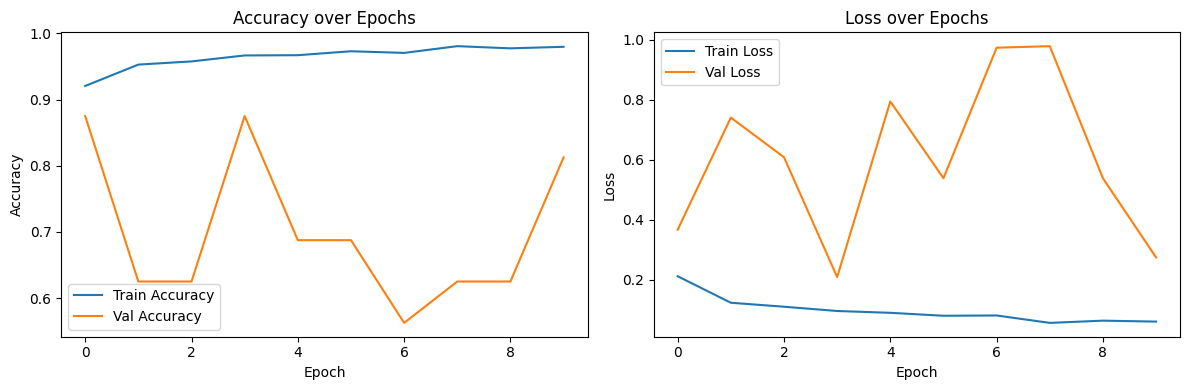

In [ ]:
# PLOT TRAINING CURVES

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_accs, label='Train Accuracy')
axes[0].plot(val_accs,   label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(train_losses, label='Train Loss')
axes[1].plot(val_losses,   label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
#To save the model 

import os

torch.save(model.state_dict(), "chest_pneumonia_model.pth")

# Check it really exists and see its size
size = os.path.getsize("chest_pneumonia_model.pth")
print(f"File exists: {os.path.exists('chest_pneumonia_model.pth')}")
print(f"File size  : {size / 1024 / 1024:.2f} MB")

# Now download
from google.colab import files 
files.download("chest_pneumonia_model.pth")

File exists: True
File size  : 17.67 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>